In [3]:
import torch
import numpy as np
import networkx as nx
from torch_geometric.datasets import TUDataset
from collections import defaultdict, Counter

# Load MUTAG
dataset = TUDataset(root="data/TUDataset", name="MUTAG")

print("Number of graphs:", len(dataset))
print("Node features:", dataset.num_node_features)
print("Classes:", dataset.num_classes)

Processing...


Number of graphs: 188
Node features: 7
Classes: 2


Done!


In [4]:
def pyg_to_nx(data):
    edge_index = data.edge_index.numpy()
    G = nx.Graph()
    G.add_nodes_from(range(data.num_nodes))
    
    edges = list(zip(edge_index[0], edge_index[1]))
    G.add_edges_from(edges)
    
    return G

train_graphs = [pyg_to_nx(data) for data in dataset]

In [5]:
node_counts = [G.number_of_nodes() for G in train_graphs]
count_distribution = Counter(node_counts)

print(count_distribution)

Counter({17: 18, 23: 18, 13: 17, 19: 16, 16: 16, 22: 15, 11: 14, 20: 14, 12: 13, 21: 8, 14: 7, 15: 7, 25: 6, 26: 5, 18: 4, 24: 4, 28: 3, 10: 2, 27: 1})


In [6]:
def graph_density(G):
    n = G.number_of_nodes()
    if n <= 1:
        return 0
    possible_edges = n * (n - 1) / 2
    return G.number_of_edges() / possible_edges

densities_by_n = defaultdict(list)

for G in train_graphs:
    n = G.number_of_nodes()
    densities_by_n[n].append(graph_density(G))

avg_density_by_n = {
    n: np.mean(densities)
    for n, densities in densities_by_n.items()
}

In [7]:
def sample_er_graph(node_counts, avg_density_by_n):
    N = np.random.choice(node_counts)
    r = avg_density_by_n[N]
    G = nx.erdos_renyi_graph(N, r)
    return G

In [8]:
baseline_graphs = [
    sample_er_graph(node_counts, avg_density_by_n)
    for _ in range(1000)
]

print("Generated baseline graphs:", len(baseline_graphs))

Generated baseline graphs: 1000


In [ ]:
# Make graph hashes
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash

def graph_hash(G):
    return weisfeiler_lehman_graph_hash(G)

In [ ]:
# Hash training graphs
train_hashes = [graph_hash(G) for G in train_graphs]
train_hash_set = set(train_hashes)

c:\Users\marah\miniconda3\Lib\site-packages\networkx\algorithms\graph_hashing.py:211: UserWarning: The hashes produced for graphs without node or edge attributes changed in v3.5 due to a bugfix (see documentation).
  node_labels = _init_node_labels(G, edge_attr, node_attr)


In [11]:
# Hash baseline graphs
baseline_hashes = [graph_hash(G) for G in baseline_graphs]

Compute novelty

Novel means:

    generated graph is different from all training graphs.

In [12]:
novel = [
    h not in train_hash_set
    for h in baseline_hashes
]

novel_percent = 100 * np.mean(novel)
print("Novel baseline %:", novel_percent)

Novel baseline %: 100.0


Compute uniqueness

Unique means:

    generated graph is not just repeated many times.

In [13]:
unique_percent = 100 * len(set(baseline_hashes)) / len(baseline_hashes)
print("Unique baseline %:", unique_percent)

Unique baseline %: 99.9


In [14]:
#Compute novel + unique
novel_unique_hashes = {
    h for h in baseline_hashes
    if h not in train_hash_set
}

novel_unique_percent = 100 * len(novel_unique_hashes) / len(baseline_hashes)
print("Novel + unique baseline %:", novel_unique_percent)

Novel + unique baseline %: 99.9


In [15]:
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash
import numpy as np

def graph_hash(G):
    return weisfeiler_lehman_graph_hash(G)

# Hash training graphs
train_hashes = [graph_hash(G) for G in train_graphs]
train_hash_set = set(train_hashes)

# Hash baseline graphs
baseline_hashes = [graph_hash(G) for G in baseline_graphs]

# 1. Novelty
novel_percent = 100 * np.mean([
    h not in train_hash_set
    for h in baseline_hashes
])

# 2. Uniqueness
unique_percent = 100 * len(set(baseline_hashes)) / len(baseline_hashes)

# 3. Novel + unique
novel_unique_hashes = {
    h for h in baseline_hashes
    if h not in train_hash_set
}

novel_unique_percent = 100 * len(novel_unique_hashes) / len(baseline_hashes)

print(f"Novel baseline: {novel_percent:.2f}%")
print(f"Unique baseline: {unique_percent:.2f}%")
print(f"Novel + unique baseline: {novel_unique_percent:.2f}%")

c:\Users\marah\miniconda3\Lib\site-packages\networkx\algorithms\graph_hashing.py:211: UserWarning: The hashes produced for graphs without node or edge attributes changed in v3.5 due to a bugfix (see documentation).
  node_labels = _init_node_labels(G, edge_attr, node_attr)


Novel baseline: 100.00%
Unique baseline: 99.90%
Novel + unique baseline: 99.90%


In [17]:
def degree_values(graphs):
    values = []
    for G in graphs:
        values.extend([d for _, d in G.degree()])
    return values

def clustering_values(graphs):
    values = []
    for G in graphs:
        values.extend(nx.clustering(G).values())
    return values

def eigenvector_values(graphs):
    values = []
    for G in graphs:
        try:
            centrality = nx.eigenvector_centrality(G, max_iter=1000)
            values.extend(centrality.values())
        except nx.PowerIterationFailedConvergence:
            pass
    return values

train_degree = degree_values(train_graphs)
baseline_degree = degree_values(baseline_graphs)

train_clustering = clustering_values(train_graphs)
baseline_clustering = clustering_values(baseline_graphs)

train_eigenvector = eigenvector_values(train_graphs)
baseline_eigenvector = eigenvector_values(baseline_graphs)

print("Finished computing graph statistics")

Finished computing graph statistics


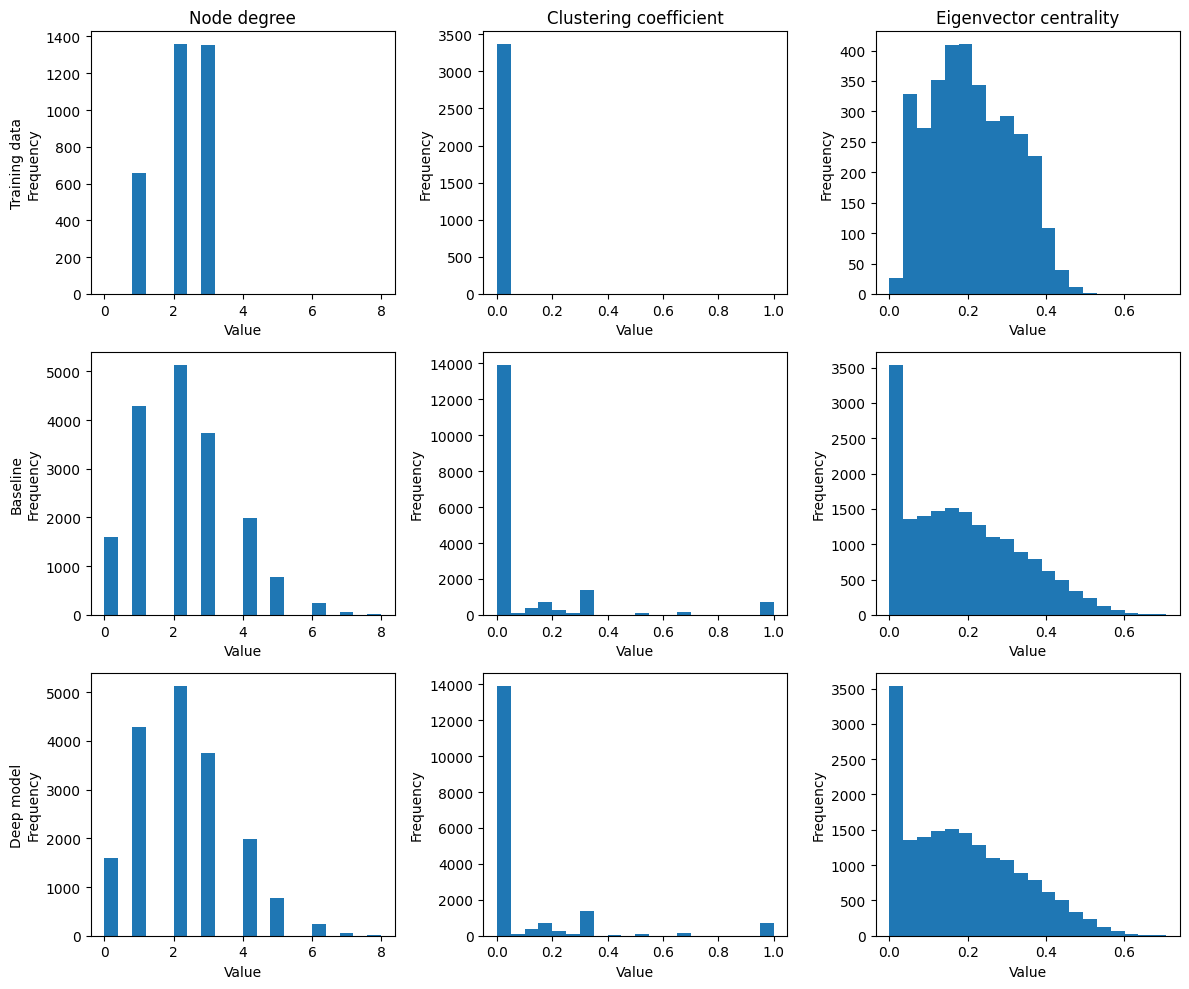

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Temporary placeholder until the deep generative model is ready
deep_graphs = baseline_graphs

deep_degree = degree_values(deep_graphs)
deep_clustering = clustering_values(deep_graphs)
deep_eigenvector = eigenvector_values(deep_graphs)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

statistics = [
    ("Node degree", train_degree, baseline_degree, deep_degree),
    ("Clustering coefficient", train_clustering, baseline_clustering, deep_clustering),
    ("Eigenvector centrality", train_eigenvector, baseline_eigenvector, deep_eigenvector),
]

row_labels = ["Training data", "Baseline", "Deep model"]

for col, (stat_name, train_vals, baseline_vals, deep_vals) in enumerate(statistics):
    all_vals = np.array(train_vals + baseline_vals + deep_vals)
    bins = np.histogram_bin_edges(all_vals, bins=20)

    values_by_row = [train_vals, baseline_vals, deep_vals]

    for row, values in enumerate(values_by_row):
        ax = axes[row, col]
        ax.hist(values, bins=bins)
        
        if row == 0:
            ax.set_title(stat_name)
        
        if col == 0:
            ax.set_ylabel(row_labels[row])
        
        ax.set_xlabel("Value")
        ax.set_ylabel(ax.get_ylabel() + "\nFrequency" if col == 0 else "Frequency")

plt.tight_layout()
plt.show()